In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# このnotebook用に変更する
# =========================
FIG_DIR_NAME = "fig8_B"  # fig4_B, fig5, fig7, fig8_B に変更

# =========================
# project root を探す
# =========================
def find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "rumor_model.py").exists() and (p / "fig_experiments.py").exists():
            return p
    raise FileNotFoundError("rumor_model.py と fig_experiments.py が見つかりません")

PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / FIG_DIR_NAME
FIG_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from rumor_model import (
    ADVISOR,
    LIAR,
    LIKE_TFT,
    CONDITIONAL_ADVISOR,
)

from fig_experiments import (
    run_checkpoint_experiment,
    plot_result_scatter,
    summarize_trials,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム
FIG_DIR: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig8_B


In [6]:
T_values = list(range(50,201,50)) + list(range(300,601,100))
print(T_values)

[50, 100, 150, 200, 300, 400, 500, 600]


In [9]:
fig8B_summary, fig8B_trials = run_checkpoint_experiment(
    fig_name="fig8_B",
    target_strategy=CONDITIONAL_ADVISOR,
    opponent_strategy=LIAR,
    T_values=T_values,
    r_values=list(range(0, 21)),
    freq_values=[0.9],
    g=10,
    repeat=100,
    max_generations=500,
    result_dir=FIG_DIR,
    n_jobs=6,
    chunk_size=12,
    base_seed=800000,
)

new experiment
figure         : fig8_B
result_dir     : c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig8_B
all tasks      : 16800
done           : 0
remaining      : 16800
repeat         : 100
max_generations: 500
n_jobs         : 6
chunk_size     : 12
fig8_B: 16800 / 16800 finished (130.5 min)


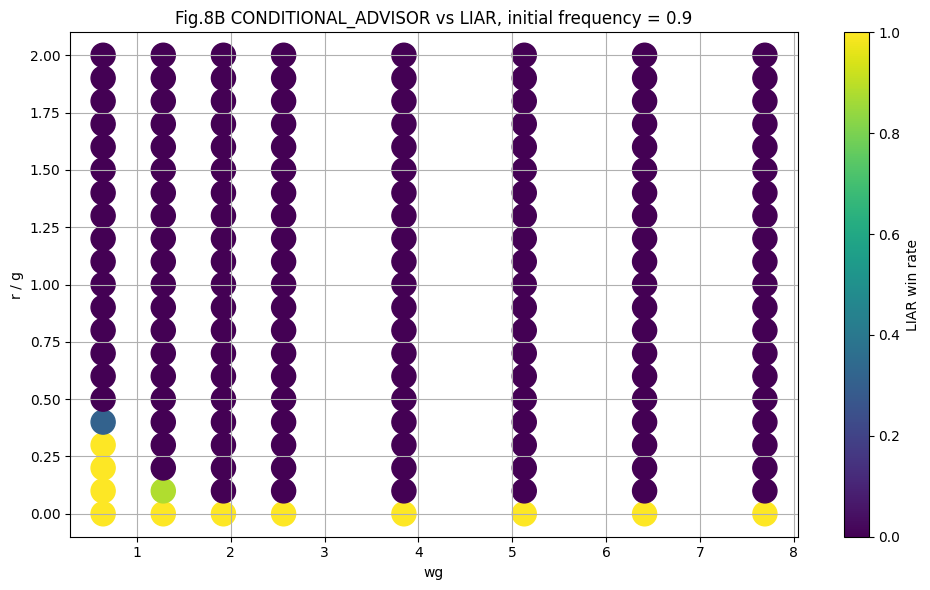

In [10]:
plot_result_scatter(
    df_summary=fig8B_summary,
    x_col="wg",
    y_col="r_over_g",
    color_col="opponent_win_rate",
    title="Fig.8B CONDITIONAL_ADVISOR vs LIAR, initial frequency = 0.9",
    save_path=FIG_DIR / "fig8_B_scatter.png",
    xlabel="wg",
    ylabel="r / g",
    color_label="LIAR win rate",
)